# PHYS 332 - Numerical Techniques for the Sciences II
## Homework 01: Ordinary Differential Equations
### Problem 4 -  The Kepler Problem
---
Name: *Ethan Duarte*

Cells for *Problem 4* is below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Your RK45 Step and Stepping Function go Here

In [2]:
def rk45step(y,f,x,h):

    c = np.array([np.nan, 1/5, 3/10, 4/5, 8/9, 1, 1])

    a = np.array([[np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
                  [1/5, np.nan, np.nan, np.nan, np.nan, np.nan],
                  [3/40, 9/40, np.nan, np.nan, np.nan, np.nan],
                  [44/45, -56/15, 32/9, np.nan, np.nan, np.nan],
                  [19372/6561, -25360/2187, 64448/6561, -212/729, np.nan, np.nan],
                  [9017/3168, -355/33, 46732/5247, 49/176, -5103/18656, np.nan],
                  [35/384, 0, 500/1113, 125/192, -2187/6784, 11/84]])

    b = np.array([35/384, 0, 500/1113, 125/192, -2187/6784, 11/84, 0])

    bstar = np.array([5179/57600, 0, 7571/16695, 393/640,
                      -92097/339200, 187/2100, 1/40])


    k1 = h * f(x,y)

    k2 = h * f(x + c[1] * h,
               y + a[1][0] * k1)

    k3 = h * f(x + c[2] * h,
               y + a[2][0] * k1 + a[2][1] * k2)

    k4 = h * f(x + c[3] * h,
               y + a[3][0] * k1 + a[3][1] * k2 + a[3][2] * k3)

    k5 = h * f(x + c[4] * h,
               y + a[4][0] * k1 + a[4][1] * k2
                 + a[4][2] * k3 + a[4][3] * k4)

    k6 = h * f(x + c[5] * h,
               y + a[5][0] * k1 + a[5][1] * k2
                 + a[5][2] * k3 + a[5][3] * k4
                 + a[5][4] * k5)


    ynew = y + b[0] * k1 + b[1] * k2 + b[2] * k3 \
             + b[3] * k4 + b[4] * k5 + b[5] * k6


    k7 = h * f(x + h, ynew)


    ynewstar = y + bstar[0] * k1 + bstar[1] * k2 \
                 + bstar[2] * k3 + bstar[3] * k4 \
                 + bstar[4] * k5 + bstar[5] * k6 \
                 + bstar[6] * k7


    error = ynew - ynewstar

    return(ynew, error)

def ode_adaptivestep(f,x0,y0,x1,errtol,h0):

    x = x0
    y = y0
    h = h0

    abs_tol = 1e-10
    s = 0.9

    x_outputs = [x]
    y_outputs = [y]

    while x < x1:

        h = min(h, x1 - x)

        ynew, delta = rk45step(y, f, x, h)

        scale = abs_tol + np.maximum(np.abs(y), np.abs(ynew)) * errtol

        err = np.sqrt(np.mean((delta / scale) ** 2))

        err = max(err, 1e-16)

        hnew = s * h * (1 / err) ** (1/5)

        if err <= 1:

            x = x + h
            y = ynew

            x_outputs.append(x)
            y_outputs.append(y)

        h = hnew

    return np.array(x_outputs), np.array(y_outputs)

## Initial Conditions for the Solar System.  

These are taken from the NASA Horizons database.  Note that I'm using a system of units where the gravitational constant ($G$), the mass of the Sun ($M_{\odot}$), and the average distance between the Earth and the Sun (called an astronomical unit, $1AU$), are all equal to 1.

$$G = M_{\odot} = 1AU = 1$$

This may seem odd, but if you think about it, it's actually a lot easier in terms of having large and small numbers floating around in our simulation (e.g. in SI), where the mass of the Sun is $2\times10^{30}kg$, $G$ is $6.67\times10^{-11}m^3/kg/s^2$, and so on.  These can often lead to significant roundoff error if you're not careful, so better to normalize.

Note that in this coordinate system, 1 year is equal to $2\pi$.  So if you run your simulation for a total time of $T=62.83185$, that's running it for 10 years, and so on. 

In [3]:
masses = np.array([
    1.00000000e+00,
    1.66012083e-07,
    2.44783829e-06,
    3.04043265e-06,
    3.22715608e-07,
    9.54791910e-04,
    2.85885670e-04,
    4.36624961e-05,
    5.15138377e-05
])

y0 = np.array([
    [-1.49396118e-03, -5.23611878e-03,  9.98870832e-05,
      3.61189681e-04,  1.29328734e-04, -7.53790986e-06],

    [-1.66152953e-01,  2.69665431e-01,  3.76678614e-02,
     -1.73217164e+00, -7.77577317e-01,  9.53371148e-02],

    [ 2.39139993e-01, -6.91778625e-01, -2.32167774e-02,
      1.10203999e+00,  3.85065758e-01, -5.82846595e-02],

    [ 8.57031590e-01, -5.40328553e-01,  1.26911356e-04,
      5.13158445e-01,  8.45154972e-01, -6.13573781e-05],

    [ 6.48967620e-01,  1.35320894e+00,  1.26184060e-02,
     -7.02472319e-01,  4.20677538e-01,  2.60394863e-02],

    [-3.25227884e+00,  4.17227928e+00,  5.54783211e-02,
     -3.51236311e-01, -2.49019009e-01,  8.89400911e-03],

    [ 9.30989664e+00,  1.53946375e+00, -3.97451554e-01,
     -7.07230731e-02,  3.19261345e-01, -2.73659360e-03],

    [ 9.07194640e+00,  1.71970299e+01, -5.36609220e-02,
     -2.03912570e-01,  9.60238562e-02,  2.99815852e-03],

    [ 2.98427431e+01,  1.24716629e+00, -7.13439736e-01,
     -8.81969730e-03,  1.83408507e-01, -3.57374310e-03]
])

## These are set up so that the ith element of masses gives you the mass of the ith body, 
## and the ith element of y0 gives you it's initial conditions.  The bodies are

## 0 - Sun
## 1 - Mercury
## 2 - Venus
## 3 - Earth
## 4 - Mars
## 5 - Jupiter
## 6 - Saturn
## 7 - Neptune
## 8 - Uranus

## As an example, masses[0] gives you the mass of the Sun, while y0[0] gives you the [x,y,z,vx,vy,vz] array for the Sun

## Part B: Right Hand Side for the Kepler Problem
Code up your equations from Part A into a callable function that returns $\frac{dy}{dx}$ for the Kepler problem (here $\vec{y}$ is the state vector for every mass, that is it's position and velocity, and $x$ is time).

Note that I've set this up as operations on a 9x6 array, but you could flatten this into a 54 element array using `y.flatten()`.  Just be careful with your indicies if you do!

In [4]:
def RHS(x,y):

    dydx = np.zeros_like(y)

    for i in range(9):

        dydx[i][0] = y[i][3]
        dydx[i][1] = y[i][4]
        dydx[i][2] = y[i][5]

        for j in range(9):

            if i == j:
                continue

            dx = y[j][0] - y[i][0]
            dy = y[j][1] - y[i][1]
            dz = y[j][2] - y[i][2]

            r = np.sqrt(dx**2 + dy**2 + dz**2)

            dydx[i][3] += masses[j] * dx / r**3
            dydx[i][4] += masses[j] * dy / r**3
            dydx[i][5] += masses[j] * dz / r**3

    return dydx

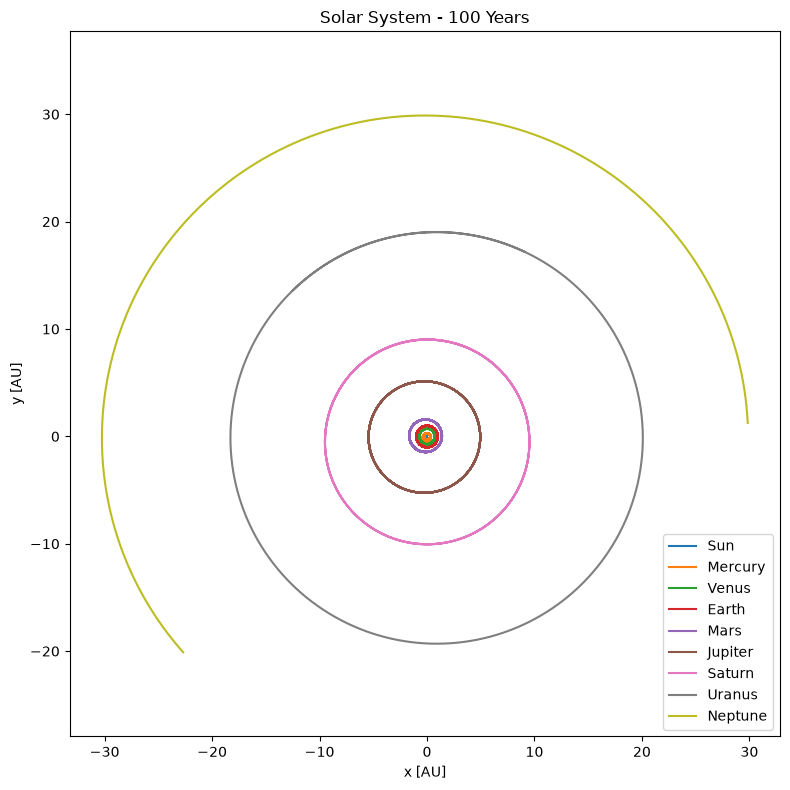

In [5]:
t, Y = ode_adaptivestep(
    RHS,
    0,
    y0,
    2 * np.pi * 100,
    1e-5,
    0.01
)

names = [
    "Sun",
    "Mercury",
    "Venus",
    "Earth",
    "Mars",
    "Jupiter",
    "Saturn",
    "Uranus",
    "Neptune"
]

plt.figure(figsize=(8,8))

for i in range(9):

    plt.plot(
        Y[:,i,0],
        Y[:,i,1],
        label=names[i]
    )

plt.xlabel("x [AU]")
plt.ylabel("y [AU]")
plt.title("Solar System - 100 Years")

plt.axis("equal")
plt.legend()

plt.tight_layout()
plt.show()

0.00010944025253668922 -0.00022172315245988684
0.00010943054060629148 -0.00022171344052948044
0.00010934220112860437 -0.00022162510253805143
0.00010925215790956351 -0.00022153505652556887
0.00010916327810497755 -0.0002214461736651709
0.00010907833203284274 -0.00022136122523658456
0.000108991813378102 -0.00022127470369120823
0.00010892265229598665 -0.000221205542041995
0.00010885821552850016 -0.00022114110637667375
0.0001088141098335985 -0.00022109700447917757
0.00010878500052780574 -0.00022106793042416363
0.00010877630793594099 -0.00022105925439495723
0.00010877038415936334 -0.00022105335018780684
0.00010875598449847054 -0.00022103896300289214
0.00010872282426207261 -0.0002210058178681905
0.0001086692341217591 -0.00022095223642480536
0.00010860155846469236 -0.00022088456253855127
0.00010851852472744501 -0.00022080152710217765
0.00010843840417005292 -0.00022072140400109604
0.00010836112926072959 -0.0002206441271363082
0.00010827748957686331 -0.00022056048434296912
0.00010819898537397013

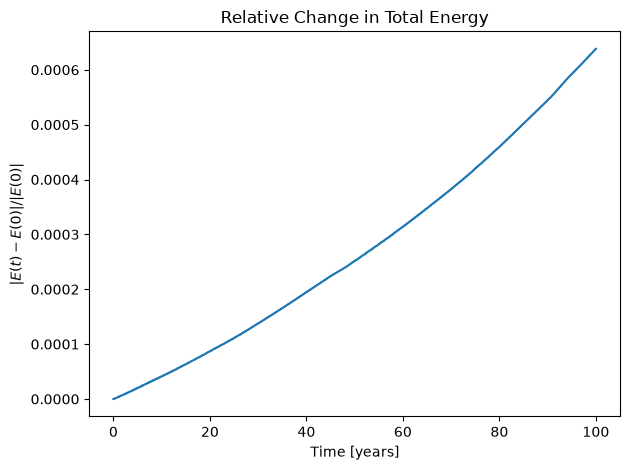

Maximum Relative Energy Change: 0.0006381646171670948


In [10]:
def total_energy(state):

    kinetic = 0
    potential = 0

    for i in range(9):

        vx = state[i][3]
        vy = state[i][4]
        vz = state[i][5]

        v2 = vx**2 + vy**2 + vz**2

        kinetic += 0.5 * masses[i] * v2


    for i in range(9):

        for j in range(i + 1, 9):

            dx = state[j][0] - state[i][0]
            dy = state[j][1] - state[i][1]
            dz = state[j][2] - state[i][2]

            r = np.sqrt(dx**2 + dy**2 + dz**2)

            potential -= masses[i] * masses[j] / r

    print(kinetic, potential)


    return kinetic + potential


E = []

for state in Y:

    E.append(total_energy(state))

E = np.array(E)

relative_energy_change = np.abs(E - E[0]) / np.abs(E[0])

years = t / (2 * np.pi)

plt.plot(years, relative_energy_change)

plt.xlabel("Time [years]")
plt.ylabel(r"$|E(t)-E(0)|/|E(0)|$")
plt.title("Relative Change in Total Energy")

plt.tight_layout()
plt.show()

print("Maximum Relative Energy Change:", np.max(relative_energy_change))

In [9]:
#Animation provided by ChatGPT because I wanted to see it. 

# ============================================================
# ANIMATION
# ============================================================

import matplotlib as mpl
import imageio_ffmpeg

from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import Video

# Tell Matplotlib where ffmpeg is
mpl.rcParams["animation.ffmpeg_path"] = imageio_ffmpeg.get_ffmpeg_exe()


# Uniform times so the animation runs steadily
nframes = 3000

t_anim = np.linspace(
    t[0],
    t[-1],
    nframes
)

Y_anim = np.zeros(
    (nframes, 9, 6)
)

for i in range(9):

    for j in range(6):

        Y_anim[:,i,j] = np.interp(
            t_anim,
            t,
            Y[:,i,j]
        )


# Set up figure
fig, ax = plt.subplots(figsize=(8,8))

ax.set_xlim(-35,35)
ax.set_ylim(-35,35)
ax.set_aspect("equal")

ax.set_xlabel("x [AU]")
ax.set_ylabel("y [AU]")


points = []
trails = []

for i in range(9):

    trail, = ax.plot([], [], lw=1)
    point, = ax.plot([], [], "o", label=names[i])

    trails.append(trail)
    points.append(point)


ax.legend(loc="upper right")

trail_length = 60


def update(frame):

    for i in range(9):

        points[i].set_data(
            [Y_anim[frame,i,0]],
            [Y_anim[frame,i,1]]
        )

        start = max(
            0,
            frame - trail_length
        )

        trails[i].set_data(
            Y_anim[start:frame+1,i,0],
            Y_anim[start:frame+1,i,1]
        )

    ax.set_title(
        f"Solar System — {t_anim[frame] / (2*np.pi):.1f} years"
    )

    return points + trails


anim = FuncAnimation(
    fig,
    update,
    frames=nframes,
    interval=20,
    blit=False
)

plt.close(fig)


# Save and display
writer = FFMpegWriter(
    fps=30,
    codec="h264",
    bitrate=3000
)

anim.save(
    "solar_system.mp4",
    writer=writer,
    dpi=120
)

Video(
    "solar_system.mp4",
    embed=False
)